<a href="https://colab.research.google.com/github/wernst24/imgs362/blob/main/hw2/LE_Fashion_MNIST_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import v2

In [11]:
basic_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,))
])

augment_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,)),
    v2.RandomResizedCrop(size=(30, 30), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True)
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=basic_transforms)

augmented_train_dataset = datasets.FashionMNIST(root='./data_augmented', train=True, download=True, transform=augment_transforms)

test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=basic_transforms)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of augmented training samples: {len(augmented_train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 60000
Number of augmented training samples: 60000
Number of test samples: 10000


In [13]:
# Create DataLoaders for batching and shuffling
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
augmented_train_loader = DataLoader(augmented_train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of augmented training batches: {len(augmented_train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 938
Number of augmented training batches: 938
Number of test batches: 157


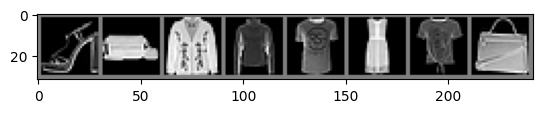

Sandal Bag   Coat  Pullover T-shirt/top Dress T-shirt/top Bag  


In [5]:
# Function to unnormalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Get one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images[:8])) # Display first 8 images

# Print labels (class names)
classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

In [23]:
# Define the CNN model
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # First convolutional block
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # Input to first FC layer: 64 channels * (28 / 2 / 2) * (28 / 2 / 2) = 64 * 7 * 7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 classes for FashionMNIST

    def forward(self, x):
        # Apply first convolutional block
        x = self.pool1(F.relu(self.conv1(x)))
        # Apply second convolutional block
        x = self.pool2(F.relu(self.conv2(x)))

        # Flatten the output for the fully connected layers
        x = x.view(-1, 64 * 7 * 7)

        # Apply fully connected layers with ReLU activation
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate the model
model = FashionCNN()
augmented_model = FashionCNN()
print(model)

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [24]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
augmented_optimizer = optim.Adam(augmented_model.parameters(), lr=0.001)

# Check if CUDA is available and move model to GPU if it is
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
augmented_model.to(device)

print(f"Models moved to: {device}")

Models moved to: cuda


In [19]:
epochs = 10
train_losses = []

for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f'Epoch {epoch+1}, Loss: {avg_train_loss:.3f}')

print('Finished Training')


Epoch 1, Loss: 0.427
Epoch 2, Loss: 0.275
Epoch 3, Loss: 0.228
Epoch 4, Loss: 0.194
Epoch 5, Loss: 0.170
Epoch 6, Loss: 0.145
Epoch 7, Loss: 0.125
Epoch 8, Loss: 0.104
Epoch 9, Loss: 0.088
Epoch 10, Loss: 0.073
Finished Training


In [25]:
epochs = 10
augmented_train_losses = []

for epoch in range(epochs):
    augmented_running_loss = 0.0
    for i, data in enumerate(augmented_train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        augmented_optimizer.zero_grad()

        outputs = augmented_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        augmented_optimizer.step()

        augmented_running_loss += loss.item()

    avg_train_loss = augmented_running_loss / len(augmented_train_loader)
    augmented_train_losses.append(avg_train_loss)
    print(f'Epoch {epoch+1}, Loss: {avg_train_loss:.3f}')

print('Finished augmented Training')

Epoch 1, Loss: 1.076
Epoch 2, Loss: 0.842
Epoch 3, Loss: 0.770
Epoch 4, Loss: 0.715
Epoch 5, Loss: 0.682
Epoch 6, Loss: 0.661
Epoch 7, Loss: 0.641
Epoch 8, Loss: 0.626
Epoch 9, Loss: 0.617
Epoch 10, Loss: 0.603
Finished augmented Training


In [ ]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders for the original CNN training (with validation split)
train_loader_orig = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader_orig = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples (original split): {len(train_subset)}")
print(f"Number of validation samples (original split): {len(val_subset)}")

Number of training samples (original split): 48000
Number of validation samples (original split): 12000


### Step 2: Define Augmented Transformations and DataLoaders for the augmented CNN

In [ ]:
# Define transformations with augmentation
transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(28, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Create an augmented dataset from the training subset
# We need to apply the augmented transform to the training subset
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

augmented_train_dataset = AugmentedDataset(train_subset, transform=transform_augmented)
augmented_train_loader = DataLoader(augmented_train_dataset, batch_size=batch_size, shuffle=True)

print(f"Number of augmented training samples: {len(augmented_train_dataset)}")

Number of augmented training samples: 48000


In [ ]:
def train_and_evaluate_cnn(model, train_loader, val_loader, test_loader, epochs, device, model_name="Model"):
    print(f"\nTraining {model_name}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses_history = []
    val_losses_history = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses_history.append(avg_train_loss)

        # Validation phase
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses_history.append(avg_val_loss)

        print(f'Epoch {epoch+1}, Train Loss: {avg_train_loss:.3f}, Val Loss: {avg_val_loss:.3f}')

    print(f'Finished Training {model_name}')

    # Evaluate on test set
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the {model_name} on the 10000 test images: {accuracy:.2f}%')

    return train_losses_history, val_losses_history, accuracy

In [ ]:
model_cnn_original = FashionCNN()
model_cnn_original.to(device)

train_losses_orig, val_losses_orig, acc_orig = train_and_evaluate_cnn(
    model_cnn_original, train_loader_orig, val_loader_orig, test_loader, epochs=10, device=torch.device("cuda"), model_name="Original CNN")


Training Original CNN...
Epoch 1, Train Loss: 0.462, Val Loss: 0.329
Epoch 2, Train Loss: 0.297, Val Loss: 0.302
Epoch 3, Train Loss: 0.248, Val Loss: 0.253
Epoch 4, Train Loss: 0.213, Val Loss: 0.245
Epoch 5, Train Loss: 0.183, Val Loss: 0.230
Epoch 6, Train Loss: 0.160, Val Loss: 0.224
Epoch 7, Train Loss: 0.137, Val Loss: 0.236
Epoch 8, Train Loss: 0.116, Val Loss: 0.261
Epoch 9, Train Loss: 0.099, Val Loss: 0.247
Epoch 10, Train Loss: 0.082, Val Loss: 0.269
Finished Training Original CNN
Accuracy of the Original CNN on the 10000 test images: 91.50%


In [ ]:
model_cnn_augmented = FashionCNN()
model_cnn_augmented.to(device)

train_losses_aug, val_losses_aug, acc_aug = train_and_evaluate_cnn(
    model_cnn_augmented, augmented_train_loader, val_loader_orig, test_loader, 10, device, "Augmented CNN"
)


Training Augmented CNN...


TypeError: pic should be PIL Image or ndarray. Got <class 'torch.Tensor'>

### Step 6: Plot the training and validation losses for both CNN models

In [ ]:
epochs_range = range(1, 11)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_orig, label='Train Loss (Original)')
plt.plot(epochs_range, val_losses_orig, label='Val Loss (Original)')
plt.title('Original CNN: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_losses_aug, label='Train Loss (Augmented)')
plt.plot(epochs_range, val_losses_aug, label='Val Loss (Augmented)')
plt.title('Augmented CNN: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28) # Flatten the input images
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Function to initialize weights
def init_weights(m, init_type='zero', variance=0.01):
    if isinstance(m, nn.Linear):
        if init_type == 'zero':
            nn.init.constant_(m.weight, 0)
        elif init_type == 'normal':
            nn.init.normal_(m.weight, mean=0, std=np.sqrt(variance))
        nn.init.constant_(m.bias, 0)

# Instantiate three models with different initializations
model_zero = MLP()
model_zero.apply(lambda m: init_weights(m, 'zero'))
model_zero.to(torch.device("cuda"))

model_var001 = MLP()
model_var001.apply(lambda m: init_weights(m, 'normal', variance=0.01))
model_var001.to(torch.device("cuda"))

model_var1000 = MLP()
model_var1000.apply(lambda m: init_weights(m, 'normal', variance=1000))
model_var1000.to(torch.device("cuda"))

print("Models initialized.")

Models initialized.


Now, let's train and evaluate each model separately. We will use the same number of epochs and optimizer settings for consistency.

In [ ]:
def train_and_evaluate(model, model_name, epochs=5):
    print(f"\nTraining {model_name}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses = []

    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data[0].to(torch.device("cuda")), data[1].to(torch.device("cuda"))

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f'Epoch {epoch+1}, Loss: {avg_train_loss:.3f}')

    print(f'Finished Training {model_name}')

    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data[0].to(torch.device("cuda")), data[1].to(torch.device("cuda"))
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the {model_name} on the 10000 test images: {accuracy:.2f}%')
    return accuracy, train_losses

# Train and evaluate each model
acc_zero, losses_zero = train_and_evaluate(model_zero, "MLP with Zero Initialization")
acc_var001, losses_var001 = train_and_evaluate(model_var001, "MLP with Variance 0.01 Initialization")
acc_var1000, losses_var1000 = train_and_evaluate(model_var1000, "MLP with Variance 1000 Initialization")


Training MLP with Zero Initialization...
Epoch 1, Loss: 2.303
Epoch 2, Loss: 2.303
Epoch 3, Loss: 2.303
Epoch 4, Loss: 2.303
Epoch 5, Loss: 2.303
Finished Training MLP with Zero Initialization
Accuracy of the MLP with Zero Initialization on the 10000 test images: 10.00%

Training MLP with Variance 0.01 Initialization...
Epoch 1, Loss: 0.482
Epoch 2, Loss: 0.358
Epoch 3, Loss: 0.324
Epoch 4, Loss: 0.301
Epoch 5, Loss: 0.279
Finished Training MLP with Variance 0.01 Initialization
Accuracy of the MLP with Variance 0.01 Initialization on the 10000 test images: 87.93%

Training MLP with Variance 1000 Initialization...
Epoch 1, Loss: 60210363.198
Epoch 2, Loss: 13990057.340
Epoch 3, Loss: 9500953.471
Epoch 4, Loss: 7724972.810
Epoch 5, Loss: 6659167.123
Finished Training MLP with Variance 1000 Initialization
Accuracy of the MLP with Variance 1000 Initialization on the 10000 test images: 67.23%
